# HW2: Linear Regression

Welcome to the coding part of Homework 2. In this notebook, you will implement linear regression on California Housing dataset.

# Due Date: Sunday, May 3, at 11:59 PM

This assignment is due on **Sunday, May 3, at 11:59 PM**. You must submit your work to LearnHub by this deadline.

Goals: Practical understanding of linear regression: closed-form solution, normal equations, invertibility, pseudoinverse, SVD, regularization, different residuals...

**Instructions**:

1. Carefully read each question and its requirements.
2. Complete all TODOs in the notebook. You may add extra lines of code if needed to implement your solution.
3. For manual questions, provide clear and concise written responses.
4. Test your code thoroughly to ensure it meets the requirements.

Good luck!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

# Dataset
In this homework, you will use the California Housing dataset. You can download and check the details of the dataset by running the next five cells.



In [2]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing(as_frame=True)

X = california.data
y = california.target
feature_names = list(X.columns)
target_name = california.target_names[0]

print("California dataset loaded successfully.")

California dataset loaded successfully.


In [3]:
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:
#Split the data into train and test subsets.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (16512, 8)
Shape of X_test: (4128, 8)
Shape of y_train: (16512,)
Shape of y_test: (4128,)


In [5]:
X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


In [6]:
y_train.head()

,MedHouseVal
14196,1.030
8267,3.821
17445,1.726
14265,0.934
2271,0.965


# Part I: Preprocessing (5 pts)
In this part, we will analyze the data statistics in the training set and then apply normalization. You do not need to do any coding in this part.

In [7]:
#Now, we check the train set statistics.
X_train.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.582290
std,1.904294,12.602499,2.387375,0.433215,1137.056380,11.578744,2.136665,2.005654
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000
25%,2.566700,18.000000,4.452055,1.006508,789.000000,2.428799,33.930000,-121.810000
50%,3.545800,29.000000,5.235874,1.049286,1167.000000,2.817240,34.260000,-118.510000
75%,4.773175,37.000000,6.061037,1.100348,1726.000000,3.280000,37.720000,-118.010000
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000


# **Question #1 (5 pts)**:
When you look at the mean values for each feature, what do you observe? Why do we need to apply normalization as a preprocessing?

# **Answer #1**:
The mean values are between -119 and 1426 so we have to normalize them to ensure they are on a similar scale becuase larger values will have a much larger impact and this may cause the model ignore the small values that actually have important information.

In [8]:
#We normalize the data using StandardScaler.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Part II: Linear regression with least-squares objective (27 pts)
Remember that we are trying to minimize the least-squares objective to obtain a linear model that will best explain the relation between the data and the target variable.

In this part, you are going to implement the closed-form solution for the least-squares objective and evaluate the obtained linear model on the test set.

In [9]:
#TODO (5 pts): Implement the closed form solution. This function should return the optimal weights. You should use np.linalg.inv().
def closed_form_least_squares(data, target):
  xtx = data.T@data
  xtx_inv = np.linalg.inv(xtx)
  return xtx_inv@data.T@target

#we add a column of 1s to obtain the design matrix
n, p = X_train_scaled.shape
X_train_design = np.hstack([np.ones((n, 1)), X_train_scaled])
X_test_design = np.hstack([np.ones((len(y_test), 1)), X_test_scaled])

w = closed_form_least_squares(X_train_design, y_train)

In [10]:
#TODO (3 pts): Implement the predict(X, w) function which should return the predictions of the linear model with parameters w on X.
def predict(X, w):
  return X@w

#TODO (5 pts): Implement the visualization function which should output a scatter plot. You should use matplotlib library.
#The x-axis should be the actual values, the y-axis should be the predicted values.
#Additionally, plot the x=y line which corresponds to the perfect prediction.
def visualize(pred, gt):
  plt.figure(figsize=(6,4))
  plt.scatter(gt, pred, alpha=0.6)
  plt.xlabel('Actual'); plt.ylabel('Predicted');
  plt.plot([min(gt), max(gt)], [min(gt), max(gt)], color='red')
  plt.show()

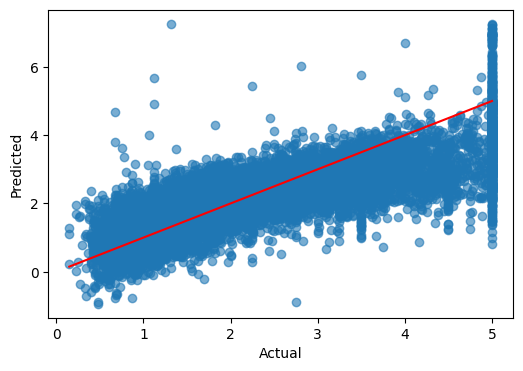

In [11]:
#predictions on train set
y_train_pred = predict(X_train_design, w)
visualize(y_train_pred, y_train)

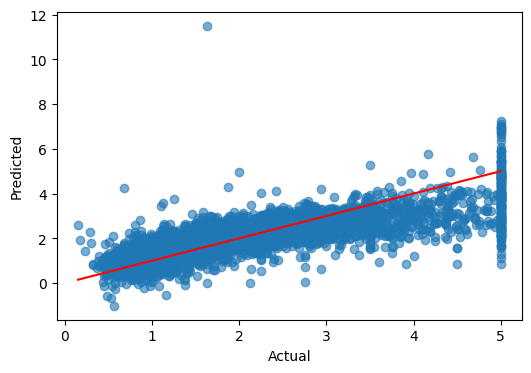

In [12]:
#predictions on test set
y_test_pred = predict(X_test_design, w)
visualize(y_test_pred, y_test)

Now you will implement 3 evaluation metrics and evaluate your linear model both on the training and test set. You should obtain the following results on the test set:

*   **MSE**: 0.56
*   **MAE**: 0.53
*   **R^2**: 0.58



In [13]:
#TODO (3 pts): Implement Mean Squared Error metric manually. Do not use external libraries.
def calculate_mse(gt, pred):
  return ((gt - pred)**2).mean()

#TODO (3 pts): Implement Mean Absolute Error metric manually. Do not use external libraries.
def calculate_mae(gt, pred):
  return np.abs(gt - pred).mean()

#TODO (3 pts): Implement R^2 (R-squared) metric manually. Do not use external libraries.
def calculate_r_squared(gt, pred):
  return 1 - (((gt - pred)**2).sum() / ((gt - gt.mean())**2).sum())

mse_train = calculate_mse(y_train, y_train_pred)
mse_test = calculate_mse(y_test, y_test_pred)

mae_train = calculate_mae(y_train, y_train_pred)
mae_test = calculate_mae(y_test, y_test_pred)

r_squared_train = calculate_r_squared(y_train, y_train_pred)
r_squared_test = calculate_r_squared(y_test, y_test_pred)

print(f'MSE on train set: {mse_train:.2f}')
print(f'MSE on test set: {mse_test:.2f}')
print("----------------")
print(f'MAE on train set: {mae_train:.2f}')
print(f'MAE on test set: {mae_test:.2f}')
print("----------------")
print(f'R^2 on train set: {r_squared_train:.2f}')
print(f'R^2 on test set: {r_squared_test:.2f}')

MSE on train set: 0.52
MSE on test set: 0.56
----------------
MAE on train set: 0.53
MAE on test set: 0.53
----------------
R^2 on train set: 0.61
R^2 on test set: 0.58


# **Question #2** (5 pts):
If you are trying to improve your model, among these metrics, which one(s) would you like to be higher and which one(s) would you like to be lower? Why?

# **Answer #2**:
MSE and MAE should be lower and R^2 should be higher because MAE and MSE shows how our models are mistaked but R^2 shows the performance of our model comparing to mean and it is closer to 1 if it is more successful then random.

# Part III: Normal Equation Gets Tricky: SVD, Pseudoinverse and Ridge (43 pts)
Remember that the data matrix in a linear regression problem may be ill-conditioned, meaning that we may not be able to derive the closed-form solution.

In this part, we will simulate this problem by adding a synthetic feature to the data matrix and then try to come up with a solution.

In [14]:
#Here, we are creating a new feature which is obtained by multiplying the 'HouseAge' column with 0.5.
idx_houseage = feature_names.index('HouseAge')
train_feat_dup = 0.5 * X_train_scaled[:, idx_houseage:idx_houseage+1]
test_feat_dup = 0.5 * X_test_scaled[:, idx_houseage:idx_houseage+1]

#Now, we are adding this new feature to the data matrix.
X_train_bad = X_train_scaled.copy()
X_test_bad = X_test_scaled.copy()
X_train_bad = np.hstack([X_train_bad, train_feat_dup])
X_test_bad = np.hstack([X_test_bad, test_feat_dup])

X_train_design_bad = np.hstack([np.ones((n,1)), X_train_bad])
X_test_design_bad = np.hstack([np.ones((len(y_test),1)), X_test_bad])

try:
  w_bad = closed_form_least_squares(X_train_design_bad, y_train)
  print(w_bad)
except Exception as e:
  print("Exception occurred: ", e)

Exception occurred:  Singular matrix


# **Question #3** (5 pts):
When you ran the cell above, what was the output? What does it mean? Why did this happen?

# **Answer #3**:
The output: Exception occurred:  Singular matrix
This happened because singular metrices are not invertible, and our data is now singular because we add a linearly dependent column.

Now, we will compute SVDs of the design matrices we have and use their pseudoinverses to obtain optimal parameters of our linear model.

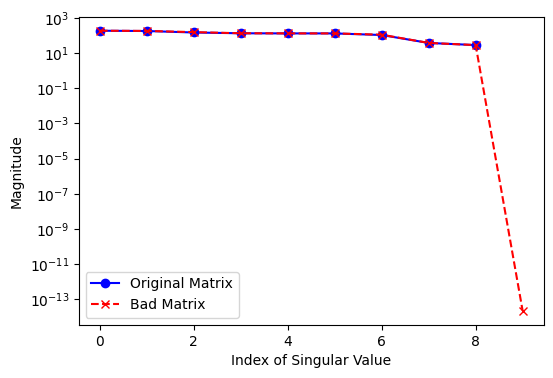

In [15]:
#TODO (8 pts): Compute SVDs for both X_train_design and X_train_design_bad and visualize the singular values for both.
#The singular values should be plotted in log scale. You can use np.linalg.svd().
svd_X_train = np.linalg.svd(X_train_design)[1]
svd_X_train_bad = np.linalg.svd(X_train_design_bad)[1]

plt.figure(figsize=(6,4))

plt.plot(svd_X_train, 'bo-', label='Original Matrix')
plt.plot(svd_X_train_bad, 'rx--', label='Bad Matrix')

plt.yscale('log')
plt.xlabel('Index of Singular Value')
plt.ylabel('Magnitude')
plt.legend()
plt.show()

# **Question #4** (5 pts):
What does SVD or singular values of a matrix correspond to? Comment on the singular values of the two design matrices.

# **Answer #4**:
Bad matrix has a singular value 0 as well as the singular values of the original matrix which are all non-zero. It shows that, original matrix is linearly independent but bad matrix is not.

In [16]:
#TODO (5 pts): Implement this function which should return the closed-form solution using the pseudo-inverse. You can use np.linalg.pinv().
def pseudoinverse_soln(data, target):
  return np.linalg.pinv(data)@target

#closed-form solution with the original data
w_pinv = pseudoinverse_soln(X_train_design, y_train)

y_train_pred_pinv = predict(X_train_design, w_pinv)
y_test_pred_pinv = predict(X_test_design, w_pinv)

mse_train_pinv = calculate_mse(y_train_pred, y_train)
mse_test_pinv = calculate_mse(y_test_pred, y_test)

#closed-form solution with the new feature
w_pinv_bad = pseudoinverse_soln(X_train_design_bad, y_train)

y_train_pred_bad = predict(X_train_design_bad, w_pinv_bad)
y_test_pred_bad = predict(X_test_design_bad, w_pinv_bad)

mse_train_bad = calculate_mse(y_train_pred_bad, y_train)
mse_test_bad = calculate_mse(y_test_pred_bad, y_test)

#you should observe that we get the same results with the pseudo-inverse solution compared to the results we got in part II.
print(f'MSE on train set (pinv): {mse_train_pinv:.2f}')
print(f'MSE on test set (pinv): {mse_test_pinv:.2f}')
print("----------------")
print(f'MSE on train set (bad): {mse_train_bad:.2f}')
print(f'MSE on test set (bad): {mse_test_bad:.2f}')

MSE on train set (pinv): 0.52
MSE on test set (pinv): 0.56
----------------
MSE on train set (bad): 0.52
MSE on test set (bad): 0.56


Another way to deal with ill-conditioned matrices is Ridge trick. Now, you will implement the closed-form solution for Ridge regression.

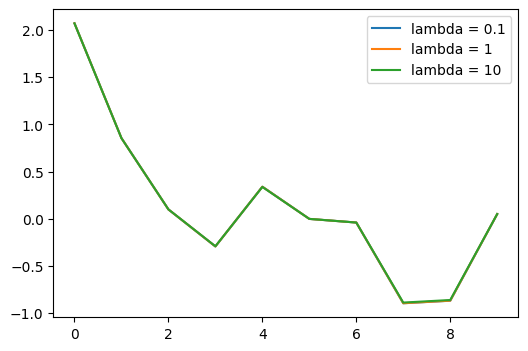

MSE on test set:
lambda = 0.1: 0.5558880076177395
lambda = 1: 0.5558558098768738
lambda = 10: 0.5555457599569604


In [17]:
#TODO (5 pts): Implement this function which should return the closed-form solution for w with Ridge regression. You can use np.linalg.inv().
def ridge_closed_form(data, target, lambda_reg):
  xtx_l = data.T@data + lambda_reg*np.eye(data.shape[1])
  xtx_l_inv = np.linalg.inv(xtx_l)
  return xtx_l_inv@data.T@target

#TODO (5 pts): Compute the optimal parameters separately with the given values for lambda.
#Visualize the resulting parameters with each lambda on a single plot.
#Output the MSE on the test set for each resulting model.
lambdas = [0.1, 1, 10]
weights = [ridge_closed_form(X_train_design_bad, y_train, l) for l in lambdas]
mse_test_ridge = [calculate_mse(predict(X_test_design_bad, w), y_test) for w in weights]

plt.figure(figsize=(6,4))
for i, l in enumerate(lambdas):
  plt.plot(weights[i], label=f'lambda = {l}')
plt.legend()
plt.show()

print(f'MSE on test set:')
for i, l in enumerate(lambdas):
  print(f'lambda = {l}: {mse_test_ridge[i]}')

# **Question #5** (10 pts):
a) How does Ridge regularization solve the invertibility problem?

b) How do the parameters of the linear model change when you increase lambda? How would you find the optimal lambda?

# **Answer #5**:
a) Adding a diagonal to a singular matrix whose determinant is 0 makes its determinant non-zero which means invertible.

b) While the lambda is increasing, MSE is decreasing but the difference is very very small in our case. I will do grid search to find the optimal lambda.

# Part IV: Error Function (25 pts)
So far, we mostly worked on linear regression with the least-squares objective. However, we can introduce other error functions that will behave differently, i.e. find different solutions for the dataset we have.

In the last part, you will be introduced to Huber regression and analyze the differences between Least-Squares and Huber regression. Specifically, we will augment the data we have to observe the behavioral changes in a better and clearer way.

You will use scikit-learn library in this part. You can check the details of Huber regression from this link: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.HuberRegressor.html.

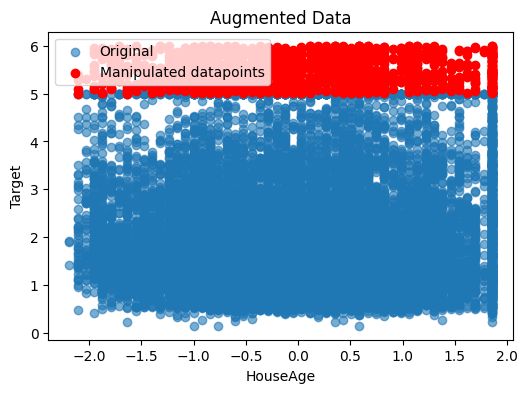

In [18]:
#Here, we randomly select 1200 datapoints and augment their target variable.
np.random.seed(42)
X_aug = X_train_scaled.copy()
y_aug = y_train.copy().to_numpy()
aug_idx = np.random.choice(len(y_aug), size=1200, replace=False)
y_aug[aug_idx] = 5.0 + np.random.rand(len(aug_idx))

#Now, we visualize the augmented dataset. We plot 'HouseAge' feature vs target for easier visualization.
plt.figure(figsize=(6,4))
plt.scatter(X_train_scaled[:, idx_houseage], y_train, label='Original', alpha=0.6)
plt.scatter(X_train_scaled[aug_idx, idx_houseage], y_aug[aug_idx], color='red', label='Manipulated datapoints')
plt.xlabel('HouseAge'); plt.ylabel('Target'); plt.legend(); plt.title('Augmented Data')
plt.show()

# **Question #6** (5 pts):
In the augmented dataset, red points represent extreme values that do not follow the original trend. What type of data augmentation was applied to generate these points (i.e., what do these new data points represent)?

# **Answer #6**:
The maximum value of the target in the original one is 5 and all of the manipulated data points are between 5 and 6 which are outliers. Also, it only modifies targets.

In [19]:
from sklearn.linear_model import HuberRegressor

#First, we compute the optimal parameters for least squares objective on both the original and augmented data.
X_design_aug = np.hstack([np.ones((n,1)), X_aug])

w_least_squares = pseudoinverse_soln(X_train_design, y_train)
w_least_squares_aug = pseudoinverse_soln(X_design_aug, y_aug)

#Now, obtain the predictions of the models obtained by least squares objective on the test set.
y_least_squares_test = X_test_design @ w_least_squares
y_least_squares_aug_test = X_test_design @ w_least_squares_aug

print(f"Least-squares: original vs. augmented: {calculate_mse(y_test, y_least_squares_test):.2f}, {calculate_mse(y_test, y_least_squares_aug_test):.2f}")

#TODO (10 pts): compute the optimal parameters for Huber objective on both the original and augmented data.
#You should check the link above to learn about the functions/attributes of HuberRegressor.
#Then, obtain the predictions of the models obtained by HuberRegressor on the test set.
#Finally, print the MSE for both models.
huber_ori = HuberRegressor()
huber_ori.fit(X_train_design, y_train)
y_huber_ori = huber_ori.predict(X_test_design)

huber_aug = HuberRegressor()
huber_aug.fit(X_design_aug, y_aug)
y_huber_aug = huber_aug.predict(X_test_design)

print(f"Huber: original vs. augmented: {calculate_mse(y_test, y_huber_ori):.2f}, {calculate_mse(y_test, y_huber_aug):.2f}")

Least-squares: original vs. augmented: 0.56, 0.61
Huber: original vs. augmented: 0.58, 0.57


# **Question #7** (10 pts):
a) How do the results differ between models trained on the original dataset versus the augmented dataset when using Least Squares and when using the Huber loss?

b) You should observe that Huber loss is more robust to the augmentation performed. Why? You should check the formulation of the Huber loss and explain how it remains robust to this type of datapoints.

# **Answer #7**:
a) For original dataset, Least-squares has better MSE then Huber but Huber has better performance for augmented data.

b) The Huber loss function is defined as:
$$L_\delta(y, f(x)) = \begin{cases}
\frac{1}{2}(y - f(x))^2 & \text{for } |y - f(x)| \le \delta \\ \delta(|y - f(x)| - \frac{1}{2}\delta) & \text{otherwise} \end{cases}$$

According to their maths, I can say Huber loss behaves like MSE for small errors but its punishment for large errors is less than leas squares and behaves like MAE.